# In this assignment, you will implement linear regression with one variable.
### 100 points total

In [1]:
## DO NOT MODIFY

# The following line of code clears variables within an ipython environment
# It is simply a convenience for marking 
%reset_selective -f a

# Import relevant libraries 
import numpy as np
import matplotlib.pyplot as plt
from numpy import loadtxt 

## Import more relevant libraries if you need (no Points)
Marker will run this import before examine your code


In [ ]:
# Import more libraries if needed

## Load data from data.csv file (5 Points)
Complete the function below to load the data from "data.csv".

The function should **return** [X, y] where X is the input and y is the target

In [9]:
import pandas as pd
def load_data(data_file):
    data=pd.read_csv(data_file)
    X=data.iloc[:,:-1].values
    y=data.iloc[:,-1].values
    
    return X, y

The below line of code simply runs the function you should have written.

In [10]:
## MARKER USE ONLY DO NOT MODIFY

[X,y] = load_data("data-2.csv")

# Visualise the data (5 Points)

Complete the function 'vis_data'. This function should provide an overview of the data including a variety of useful plots.

In [41]:
import seaborn as sns
def vis_data(x,y):
    plt.scatter(X, y, color='blue', label="Data Points")
    plt.xlabel('Input (X)')
    plt.ylabel('Target (y)')
    plt.title('Visualizing Data')
    plt.legend()
    plt.show()
  
    

    

The below line of code simply runs the function you should have written.

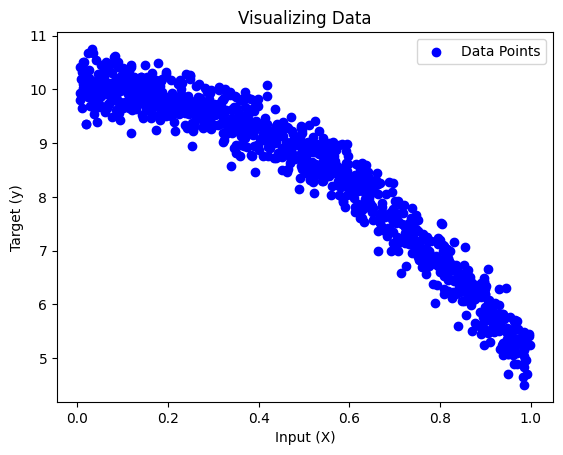

In [42]:
## MARKER USE ONLY DO NOT MODIFY

vis_data(X,y)

## Loss (10 Points)
Complete the function 'loss'. This function should calculate an appropriate loss when given the predicted and true values of 'y' (the variable being predicted).
Hint: 1. regression or classificion task? 2. what is the math equation for a regression/classification loss?

In [27]:
# y_true --> the target values.
# y_pred --> the predicted values
def loss(y_true, y_pred):    
    #Calculating loss.

    loss_value = np.mean((y_true - y_pred) ** 2)
    return loss_value

### Test loss function
Implement a test for your loss function to demonstrate it provides the correct answer when used. The **assert** keyword is helpful here.

In [28]:
loss(np.array([5, 2]), np.array([10, 3]))

np.float64(13.0)

## Calculating Gradients (20 Points)
Complete the 'gradients' function. This function should calculate the partial derivatives of linear regression. One for the weights (dw) and one for the bias term/constant term (db).
Hint: 1. what is gradient? 2. what are the math equations to compute the gradient for weight/bias?

In [30]:
#Input:
# X --> Input.
# y_true --> target values.
# y_pred --> predictions.
#return:
# dw --> the gradient with respect to the weights
# db --> the gradient with respect to the bias.
def gradients(X, y_true, y_pred):
    # write your code here
    n=X.shape[0]
    dw = (1 / n) * np.dot(X.T, (y_pred - y_true))
    db = (1 / n) * np.sum(y_pred - y_true)
    return dw, db

### Test gradients
Write tests to demonstrate that your gradient function produces the correct result. Please note that in 'computer land', the term 'equal' can be a bit problematic. Consider looking up **'assert_almost_equal'** in the numpy libraries.

In [31]:
dw,db = gradients(np.array([5]),np.array([1.5]),np.array([1.1]))
print(f'dw = {dw} , db = {db}')

dw = -1.9999999999999996 , db = -0.3999999999999999


## Training (25 Points)
Complete the 'train' function. The '...' should be changed for any additional arguments you believe the function should have (hint, it should have further arguments). It should return the weights and bias term for a linear regression model. Please note, you **must** use your previously implemented functions (rather than just copy-pasting the code).

In [ ]:
# X --> Input.
# y --> true/target value.
# w --> weights
# b --> bias
# add more arguments as you need
def train(X, y, w, b, learning_rate=0.01, num_iterations=1000):
    loss_history = []
    for i in range(num_iterations):
        y_pred = np.dot(X, w) + b  
        current_loss = loss(y, y_pred)  
        loss_history.append(current_loss)
        
        dw, db = gradients(X, y, y_pred)  
        
        w -= learning_rate * dw  
        b -= learning_rate * db  
        
    return w, b, loss_history
w = np.zeros((X.shape[1],)) 
b = 0 
w, b, loss_history = train(X, y, w, b, learning_rate=0.01, num_iterations=1000)
print("Final weights:", w)
print("Final bias:", b)
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])
        
    

Final weights: [-0.74518266]
Final bias: 8.615048700021283
Initial loss: 72.95871157185934
Final loss: 1.808045391498801


Test your function on the provided data. Please comment on the success of the training and any notable features thereof in the markdown provided below.

In [55]:
w, b = train(X, y, w, b, learning_rate=0.01, num_iterations=1000)
print(w)
print(b)
print(loss[0],loss[-1])

ValueError: too many values to unpack (expected 2)

### Write your observations here
...

## Prediction (15 Points)
Complete the 'predict' function. This function should provide a prediction of the target variable given input variables and appropriately determined weights and biases.

In [51]:
def predict(X, w, b):
    # write your code here
    
    # Returning predictions.
    return np.dot(X, w) + b

### Visualise your predictions
The code below will produce a visualisation of the real data and your model prediction. The two should bear some resemblance. If they look very different, you have probably made an error.

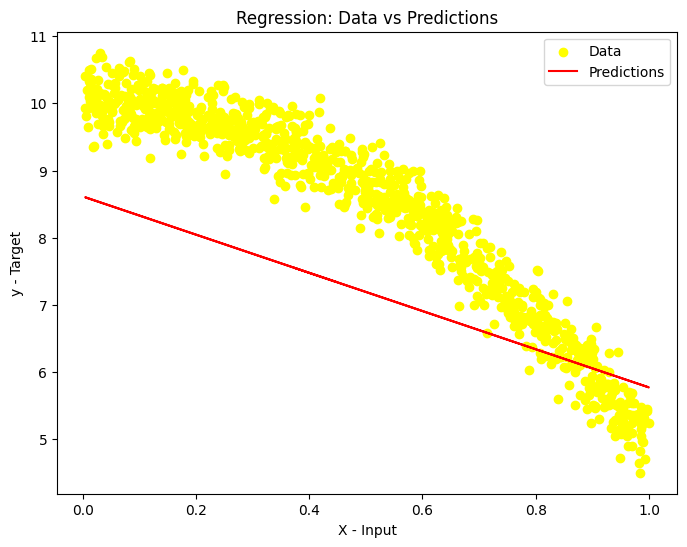

In [52]:
## MARKER USE ONLY DO NOT MODIFY

fig = plt.figure(figsize=(8,6))
plt.scatter(X, y, color='yellow', label="Data")
plt.plot(X, predict(X, w, b), color='red', label="Predictions")
plt.legend()
plt.xlabel('X - Input')
plt.ylabel('y - Target')
plt.title('Regression: Data vs Predictions')
plt.show()

### Calculate the fit score
The code below will calculate some useful metrics.

In [53]:
## MARKER USE ONLY DO NOT MODIFY

from sklearn.metrics import r2_score
y_true = y
y_pred = predict(X, w, b) ## <- Update this function signature as needed 
r2_score(y_true, y_pred)

0.14515684508205207

### Use scikit-learn to fit a linear regression model using the data from data,csv (20 points)
Now you have manually implemented linear regression, do it the easier way using scikit-learn. Consider the following things:
* Loading data
* Data description
* Training and applying models
* Evaluation metrics
* Informative and comprehensive visualisations

R² Score (scikit-learn): 0.900792951475509
Mean Squared Error (scikit-learn): 0.23527409199943217


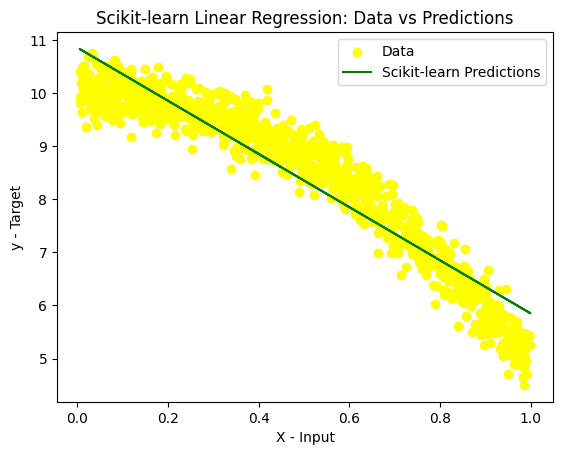

In [45]:
## Write your code here
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


model = LinearRegression()
model.fit(X, y)

y_pred_sklearn = model.predict(X)


print("R² Score (scikit-learn):", model.score(X, y))
print("Mean Squared Error (scikit-learn):", mean_squared_error(y, y_pred_sklearn))


plt.scatter(X, y, color='yellow', label="Data")
plt.plot(X, y_pred_sklearn, color='green', label="Scikit-learn Predictions")
plt.legend()
plt.xlabel('X - Input')
plt.ylabel('y - Target')
plt.title('Scikit-learn Linear Regression: Data vs Predictions')
plt.show()
